In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# PyTorch: Main deep learning library used to build and train neural networks
import torch

# nn (Neural Network): Contains predefined layers such as Linear, Conv2D,
# ReLU, Sigmoid, Loss Functions, etc.
import torch.nn as nn

# Torchvision: Provides popular datasets (MNIST, CIFAR-10, etc.)
# and computer vision utilities.
import torchvision

# Transforms: Used to preprocess images before feeding them into the model.
# Example: Convert images to tensors, normalize pixel values, resize images, etc.
import torchvision.transforms as transforms

# save_image: Saves generated or reconstructed images to a folder.
# Commonly used in Autoencoders, GANs, and image generation tasks.
from torchvision.utils import save_image

# NumPy: Used for numerical operations and array manipulation.
# Helpful for mathematical calculations and converting tensors to arrays.
import numpy as np

# Matplotlib: Used to visualize images, graphs, and training results.
import matplotlib.pyplot as plt

# datetime: Used to get the current date and time.
# Helpful for creating unique folder names or log files.
from datetime import datetime

# os: Provides functions to interact with the operating system.
# Used to create folders, check if files exist, and manage file paths.
import os

In [2]:
# ==========================================
# Image Preprocessing (Transformation)
# ==========================================

# MNIST dataset contains handwritten digit images (0 to 9).
# Each image is a grayscale image of size 28 × 28 pixels.

# Original pixel values range from 0 to 255.
# Example:
# Black pixel  = 0
# White pixel  = 255

# Deep learning models work better when input values are small.
# Therefore, we preprocess the images before feeding them to the model.

# ------------------------------------------
# Step 1: Convert image to Tensor
# ------------------------------------------
# ToTensor() performs two operations:
# 1. Converts the image into a PyTorch tensor.
# 2. Scales pixel values from:
#
#     0 - 255   --->   0.0 - 1.0
#
# Example:
# 0   becomes 0.0
# 128 becomes 0.502
# 255 becomes 1.0

# ------------------------------------------
# Step 2: Normalize the Tensor
# ------------------------------------------
# Normalize(mean=0.5, std=0.5) changes the range
# from [0, 1] to [-1, 1].
#
# Formula:
#
# Normalized Value = (Original Value - Mean) / Standard Deviation
#
# Here,
# Mean = 0.5
# Standard Deviation = 0.5
#
# Minimum value:
# (0 - 0.5) / 0.5 = -1
#
# Maximum value:
# (1 - 0.5) / 0.5 = +1
#
# Therefore,
# Pixel range changes from:
#
# 0 to 1  --->  -1 to +1
#
# This normalization helps the neural network
# train faster and improves convergence.

transform = transforms.Compose([

    # Convert image into a PyTorch Tensor
    # Pixel values: 0-255 --> 0.0-1.0
    transforms.ToTensor(),

    # Normalize pixel values
    # Range changes from:
    # 0 to 1  -->  -1 to +1
    transforms.Normalize(
        mean=(0.5,),   # Mean for grayscale images
        std=(0.5,)     # Standard deviation for grayscale images
    )
])

In [3]:
# ==========================================
# Load the MNIST Training Dataset
# ==========================================

# torchvision.datasets.MNIST() downloads and loads the
# MNIST handwritten digit dataset.

train_dataset = torchvision.datasets.MNIST(

    # root specifies the folder where the dataset
    # will be stored or loaded from.
    # '.' means the current working directory.
    root='.',

    # train=True loads the training dataset.
    # MNIST contains:
    # - 60,000 training images
    # - 10,000 testing images
    train=True,

    # Apply the preprocessing transformations
    # (ToTensor + Normalize) to every image.
    # These transformations are applied automatically
    # whenever an image is loaded.
    transform=transform,

    # If the dataset is not already available,
    # download=True automatically downloads it
    # from the internet.
    # If it already exists, it won't download again.
    download=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [4]:
len(train_dataset)

60000

In [5]:
# ==========================================
# Create a DataLoader
# ==========================================

# Batch size defines how many images are processed
# by the neural network in one iteration.
#
# Here, each batch contains 128 images.
batch_size = 128

# DataLoader is responsible for loading the dataset
# efficiently during training.
#
# Instead of feeding one image at a time,
# it divides the dataset into smaller batches.
data_loader = torch.utils.data.DataLoader(

    # The dataset to be loaded.
    # Here, it is the MNIST training dataset.
    dataset=train_dataset,

    # Number of images in one batch.
    # Each iteration returns 128 images and their labels.
    batch_size=batch_size,

    # Shuffle=True randomly changes the order of images
    # before every training epoch.
    #
    # This helps the model learn better and prevents it
    # from memorizing the order of the training data.
    shuffle=True
)

In [6]:
# ==========================================
# Discriminator Network (Artificial Neural Network)
# ==========================================

# The Discriminator's job is to determine whether
# an input image is REAL (from the dataset)
# or FAKE (generated by the Generator).

# Input:
#   Image (28 × 28 = 784 pixels)
#
# Output:
#   One value (Real or Fake)

D = nn.Sequential(

    # ------------------------------------------
    # Layer 1: Input Layer → Hidden Layer
    # ------------------------------------------

    # Input Features  : 784 (28 × 28 pixels)
    # Output Features : 512 neurons
    #
    # This layer learns basic image features
    # such as edges, curves, and simple patterns.
    nn.Linear(784, 512),

    # LeakyReLU Activation Function
    #
    # Adds non-linearity so the network can
    # learn complex relationships.
    #
    # Negative values are multiplied by 0.2
    # instead of becoming zero.
    #
    # Formula:
    # x                  if x > 0
    # 0.2 × x            if x <= 0
    #
    # This helps prevent the "Dead ReLU" problem.
    nn.LeakyReLU(0.2),

    # ------------------------------------------
    # Layer 2: Hidden Layer
    # ------------------------------------------

    # Reduces the number of neurons
    # from 512 to 256.
    #
    # Learns more meaningful features
    # from the previous layer.
    nn.Linear(512, 256),

    # Again apply LeakyReLU activation
    # to introduce non-linearity.
    nn.LeakyReLU(0.2),

    # ------------------------------------------
    # Output Layer
    # ------------------------------------------

    # Converts the 256 learned features
    # into a single output value.
    #
    # Output = 1 neuron
    #
    # This neuron represents whether
    # the image is Real or Fake.
    nn.Linear(256, 1),

    # Sigmoid is commented out because
    # the training code likely uses
    # BCEWithLogitsLoss().
    #
    # BCEWithLogitsLoss internally applies
    # the Sigmoid activation.
    #
    # If BCELoss() were used instead,
    # then Sigmoid should be enabled.
    #
    # nn.Sigmoid()
)

In [7]:
# ==========================================
# Generator Network (Artificial Neural Network)
# ==========================================

# The Generator's job is to create fake images
# that look like real MNIST handwritten digits.

# It starts with a random noise vector
# and gradually converts it into a 28 × 28 image.

# Size of the random noise vector (latent vector)
latent_dim = 100

G = nn.Sequential(

    # ------------------------------------------
    # Layer 1: Input Layer → Hidden Layer
    # ------------------------------------------

    # Input : 100 random numbers (noise vector)
    # Output: 256 neurons
    #
    # Learns the initial representation
    # for generating an image.
    nn.Linear(latent_dim, 256),

    # LeakyReLU activation introduces non-linearity.
    # Prevents the Dead ReLU problem by allowing
    # small negative values.
    nn.LeakyReLU(0.2),

    # Batch Normalization normalizes the outputs
    # of this layer.
    #
    # Benefits:
    # - Faster training
    # - Stable learning
    # - Reduces internal covariate shift
    #
    # momentum=0.7 controls how quickly
    # running statistics are updated.
    nn.BatchNorm1d(256, momentum=0.7),

    # ------------------------------------------
    # Layer 2
    # ------------------------------------------

    # Increase neurons from 256 to 512.
    # The Generator gradually expands the
    # feature representation.
    nn.Linear(256, 512),

    # Activation function
    nn.LeakyReLU(0.2),

    # Normalize outputs
    nn.BatchNorm1d(512, momentum=0.7),

    # ------------------------------------------
    # Layer 3
    # ------------------------------------------

    # Increase neurons from 512 to 1024.
    # More neurons allow the Generator to
    # learn more detailed image features.
    nn.Linear(512, 1024),

    # Activation
    nn.LeakyReLU(0.2),

    # Normalize outputs
    nn.BatchNorm1d(1024, momentum=0.7),

    # ------------------------------------------
    # Output Layer
    # ------------------------------------------

    # Convert 1024 features into 784 values.
    #
    # 784 = 28 × 28 pixels
    #
    # These 784 values represent one
    # generated MNIST image.
    nn.Linear(1024, 784),

    # Tanh activation converts output values
    # into the range [-1, +1].
    #
    # This matches the normalized MNIST images,
    # which were also scaled to [-1, 1].
    nn.Tanh()
)

In [8]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
D = D.to(device)
G = G.to(device)

In [9]:
# ==========================================
# Loss Function and Optimizers
# ==========================================

# ------------------------------------------
# Binary Cross Entropy Loss with Logits
# ------------------------------------------

# The Discriminator performs a binary classification task:
#
# Real Image  ---> Label = 1
# Fake Image  ---> Label = 0
#
# BCEWithLogitsLoss computes how different the
# predicted output is from the actual label.
#
# It internally combines:
#   1. Sigmoid Activation
#   2. Binary Cross Entropy Loss
#
# Therefore, we DO NOT add nn.Sigmoid()
# in the Discriminator's output layer.
criterion = nn.BCEWithLogitsLoss()


# ------------------------------------------
# Optimizer for the Discriminator
# ------------------------------------------

# Adam optimizer updates only the
# Discriminator's weights during training.
#
# D.parameters() tells Adam to optimize
# all trainable parameters of the Discriminator.
#
# lr = Learning Rate
# betas = Parameters controlling Adam's
# moving averages.
d_optimizer = torch.optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)


# ------------------------------------------
# Optimizer for the Generator
# ------------------------------------------

# Another Adam optimizer is created for
# the Generator.
#
# This optimizer updates ONLY the
# Generator's weights.
g_optimizer = torch.optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [10]:
# scale image back to (0, 1)
def scale_image(img):
  out = (img + 1) / 2   # -1 and 1 =>-1+1/2 = 0 and 1+1/2 =1
  return out

In [11]:
# Create a folder to store generated images
if not os.path.exists('gan_images'):
  os.makedirs('gan_images')

In [12]:
# Training loop

# labels to use in the loop
ones_ = torch.ones(batch_size, 1).to(device)
zeros_ = torch.zeros(batch_size, 1).to(device)

# save losses
d_losses = []
g_losses = []

for epoch in range(50):
  for inputs, _ in data_loader:
    # don't need targets

    # reshape and move to GPU
    n = inputs.size(0)
    inputs = inputs.reshape(n, 784).to(device)

    # set ones and zeros to correct size
    ones = ones_[:n]
    zeros = zeros_[:n]


    ###########################
    ### Train discriminator ###
    ###########################

    # real images
    real_outputs = D(inputs)
    d_loss_real = criterion(real_outputs, ones)

    # fake images
    noise = torch.randn(n, latent_dim).to(device)
    fake_images = G(noise)
    fake_outputs = D(fake_images)
    d_loss_fake = criterion(fake_outputs, zeros)

    # gradient descent step
    d_loss = 0.5 * (d_loss_real + d_loss_fake) # real_loss+fake_loss/2
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    #######################
    ### Train generator ###
    #######################

    # do it twice:
    for _ in range(2):
      # fake images
      noise = torch.randn(n, latent_dim).to(device)
      fake_images = G(noise)
      fake_outputs = D(fake_images) #-> 0

      # reverse the labels!
      g_loss = criterion(fake_outputs, ones) #-> 1

      # gradient descent step
      d_optimizer.zero_grad()
      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

    # save losses
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())


  ### print and save things ###
  print(f"Epoch: {epoch}, d_loss: {d_loss.item()}, g_loss: {g_loss.item()}")

  # PyTorch has a function to save a batch of images to file
  fake_images = fake_images.reshape(-1, 1, 28, 28)
  save_image(scale_image(fake_images), f"gan_images/{epoch+1}.png")


Epoch: 0, d_loss: 0.6797598600387573, g_loss: 0.6306086778640747
Epoch: 1, d_loss: 0.6674984097480774, g_loss: 0.6832656860351562
Epoch: 2, d_loss: 0.6816120147705078, g_loss: 0.726803183555603
Epoch: 3, d_loss: 0.690666913986206, g_loss: 0.6714960932731628
Epoch: 4, d_loss: 0.6847363710403442, g_loss: 0.7471550703048706
Epoch: 5, d_loss: 0.6714960336685181, g_loss: 0.7767624855041504
Epoch: 6, d_loss: 0.6718650460243225, g_loss: 0.7334485054016113
Epoch: 7, d_loss: 0.6860150098800659, g_loss: 0.7159602046012878
Epoch: 8, d_loss: 0.6642343997955322, g_loss: 0.7221970558166504
Epoch: 9, d_loss: 0.6958888173103333, g_loss: 0.6616018414497375
Epoch: 10, d_loss: 0.6930437088012695, g_loss: 0.7180432081222534
Epoch: 11, d_loss: 0.6998090744018555, g_loss: 0.7077056765556335
Epoch: 12, d_loss: 0.6898807287216187, g_loss: 0.724941611289978
Epoch: 13, d_loss: 0.6930818557739258, g_loss: 0.7254364490509033
Epoch: 14, d_loss: 0.6795462369918823, g_loss: 0.7142333984375
Epoch: 15, d_loss: 0.68508

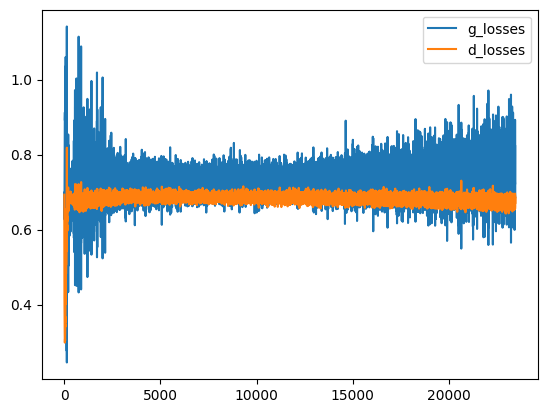

In [13]:
# ==========================================
# Plot Generator and Discriminator Losses
# ==========================================

# Plot the Generator loss values.
#
# g_losses is a list that stores the Generator
# loss after every training iteration.
#
# This line draws the Generator loss curve.
plt.plot(
    g_losses,
    label='g_losses'
)

# Plot the Discriminator loss values.
#
# d_losses stores the Discriminator loss
# after every training iteration.
#
# This line draws the Discriminator loss curve.
plt.plot(
    d_losses,
    label='d_losses'
)

# Display the legend.
#
# The legend helps identify which line
# belongs to the Generator and which
# belongs to the Discriminator.
plt.legend()

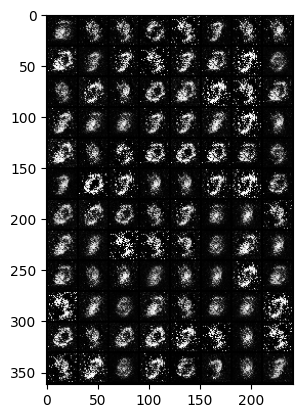

In [14]:
from skimage.io import imread
a = imread('gan_images/1.png')
plt.imshow(a)

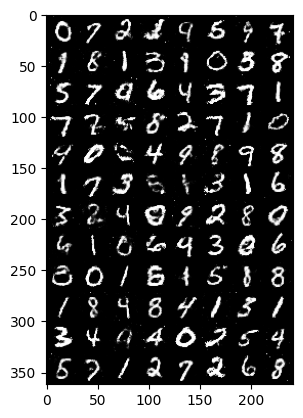

In [15]:
a = imread('gan_images/50.png')
plt.imshow(a)

In [16]:
a = imread('gan_images/100.png')
plt.imshow(a)

FileNotFoundError: No such file: '/content/gan_images/100.png'

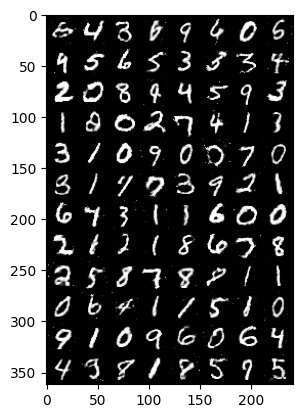

In [ ]:
a = imread('gan_images/127.png')
plt.imshow(a)

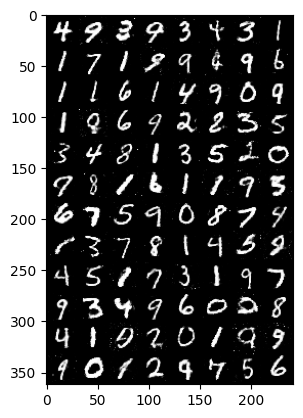

In [ ]:
a = imread('gan_images/200.png')
plt.imshow(a)